### 보스턴 주택 가격 데이터

* 주택 가격 데이터는 도시에 대한 분석과 부동산, 경제적인 정보 분석 등 많은 활용 가능한 측면들이 존재
* 보스턴 주택 가격 데이터는 카네기 멜론 대학교에서 관리하는 StatLib 라이브러리에서 가져온 것
* 헤리슨(Harrison, D.)과 루빈펠트(Rubinfeld, D. L.)의 논문 "Hedonic prices and the demand for clean air', J. Environ. Economics & Management"에서 보스턴 데이터가 사용
* 1970년도 인구 조사에서 보스턴의 506개 조사 구역과 주택 가격에 영향을 주는 속성 21개로 구성

| 속성 | 설명 |
|------|------|
| CRIM | 자치시(town)별 1인당 범죄율 |
| ZN | 25,000 평방 피트가 넘는 거주지역 토지 비율 |
| INDUS | 자치시(town)별 비소매 상업지역 토지 비율 |
| CHAS | 찰스 강(Charles River)에 대한 변수 (강의 경계에 위치하면 1, 그렇지 않으면 0) |
| NOX | 10,000,000당  일산화질소 농도 |
| RM | 주택 1가구당 평균 방의 수 |
| AGE | 1940년 이전에 건축된 소유주택 비율 |
| DIS | 5개의 보스턴 고용 센터까지의 가중 거리 |
| RAD | 방사형 고속도로 접근성 지수 |
| TAX | 10,000 달러당 재산 세율 |
| PTRATIO | 자치시(town)별 학생/교사 비율 |
| B | 1000(Bk-0.63)^2, Bk: 자치시별 흑인 비율 |
| LSTAT | 모집단의 하위계층 비율(%) |
| MEDV | 소유자가 거주하는 주택가격(중앙값) (단위: 1,000 달러) |

Boston.csv

LinearRegress, SGDRegress 를 이용하여(각각)
1) 기울기, 절편 출력
2) 0번째와 6번째 행의 데이터로 주택 중위 가격을 예측
3) 실제 medv와 예측 medv 라인차트를 그리시요
4) 각각의 결정계수값을 구하시요.

In [457]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, SGDRegressor

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


In [458]:
bostonDF = pd.read_csv('C:/machineTest/data/Boston.csv' ,index_col='Unnamed: 0')
bostonDF

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [459]:
x = bostonDF.iloc[:,:-1].values
y = bostonDF.iloc[:, [-1]].values

In [460]:
x[[0,6]]

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, 0.0000e+00, 5.3800e-01,
        6.5750e+00, 6.5200e+01, 4.0900e+00, 1.0000e+00, 2.9600e+02,
        1.5300e+01, 3.9690e+02, 4.9800e+00],
       [8.8290e-02, 1.2500e+01, 7.8700e+00, 0.0000e+00, 5.2400e-01,
        6.0120e+00, 6.6600e+01, 5.5605e+00, 5.0000e+00, 3.1100e+02,
        1.5200e+01, 3.9560e+02, 1.2430e+01]])

In [461]:
x.shape

(506, 13)

In [462]:
y

array([[24. ],
       [21.6],
       [34.7],
       [33.4],
       [36.2],
       [28.7],
       [22.9],
       [27.1],
       [16.5],
       [18.9],
       [15. ],
       [18.9],
       [21.7],
       [20.4],
       [18.2],
       [19.9],
       [23.1],
       [17.5],
       [20.2],
       [18.2],
       [13.6],
       [19.6],
       [15.2],
       [14.5],
       [15.6],
       [13.9],
       [16.6],
       [14.8],
       [18.4],
       [21. ],
       [12.7],
       [14.5],
       [13.2],
       [13.1],
       [13.5],
       [18.9],
       [20. ],
       [21. ],
       [24.7],
       [30.8],
       [34.9],
       [26.6],
       [25.3],
       [24.7],
       [21.2],
       [19.3],
       [20. ],
       [16.6],
       [14.4],
       [19.4],
       [19.7],
       [20.5],
       [25. ],
       [23.4],
       [18.9],
       [35.4],
       [24.7],
       [31.6],
       [23.3],
       [19.6],
       [18.7],
       [16. ],
       [22.2],
       [25. ],
       [33. ],
       [23.5],
       [19

In [463]:
y.shape

(506, 1)

In [464]:
model = LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


1) 기울기 절편 출력 

In [465]:
print(model.coef_)
print(model.intercept_)

[[-1.08011358e-01  4.64204584e-02  2.05586264e-02  2.68673382e+00
  -1.77666112e+01  3.80986521e+00  6.92224640e-04 -1.47556685e+00
   3.06049479e-01 -1.23345939e-02 -9.52747232e-01  9.31168327e-03
  -5.24758378e-01]]
[36.45948839]


In [466]:
model1 = SGDRegressor(verbose=1, n_iter_no_change=200)
model1.fit(x,y)

-- Epoch 1
Norm: 1011238771614.76, NNZs: 13, Bias: -3856725052.983758, T: 506, Avg. loss: 175936783398668755985667981312.000000
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 1164594835541.01, NNZs: 13, Bias: 6696194168.206383, T: 1012, Avg. loss: 81600300583703521167079899136.000000
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 1489454957194.70, NNZs: 13, Bias: 5143803598.838821, T: 1518, Avg. loss: 60015761342579146415885254656.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 1347810308436.64, NNZs: 13, Bias: 12924147756.132967, T: 2024, Avg. loss: 51861479993318757833090531328.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1322220744548.83, NNZs: 13, Bias: 12733469252.309603, T: 2530, Avg. loss: 46056165112381655816335261696.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1299418517685.14, NNZs: 13, Bias: 12789859119.703138, T: 3036, Avg. loss: 39883148756399894746844102656.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1596654

c:\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Python310\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,1
,epsilon,0.1
,random_state,None


In [467]:
print(model1.coef_)
print(model1.intercept_)

[-4.45659546e+10  1.51268803e+11  1.85295125e+11 -3.36649309e+10
  1.46323316e+10  1.51846954e+11  1.34489811e+11  1.36343871e+11
 -4.61833804e+10  8.64079409e+10 -1.25970462e+11 -2.37500643e+11
 -1.03322688e+11]
[-1.15731844e+09]


2) 0번째와 6번째 행의 데이터로 주택 중위 가격을 예측

In [468]:
x_1 = x[[0,6]]

In [469]:
# model = LinearRegression
pred = model.predict(x)

In [470]:
# model1 = SGDRegressor
# 0번째 6번째 행 가격 예측 값
pred2 = model1.predict(x[[0,6]])
pred2

array([-5.76932537e+13, -5.65325802e+13])

In [471]:
#  model = LinearRegression
# 0번째 6번째 행 가격 예측 값
pred3 = model.predict(x[[0,6]])
pred3

array([[30.00384338],
       [23.00180827]])

In [472]:
# model1 = SGDRegressor
pred1 = model1.predict(x)

3) 실제 medv와 예측 medv 라인차트를 그리시요

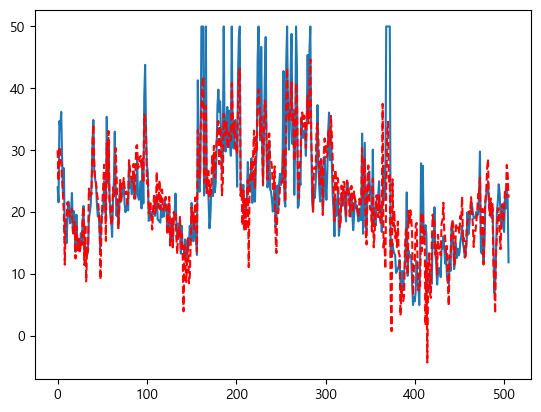

In [473]:
plt.plot(y)
plt.plot(pred, 'r--')
plt.show()

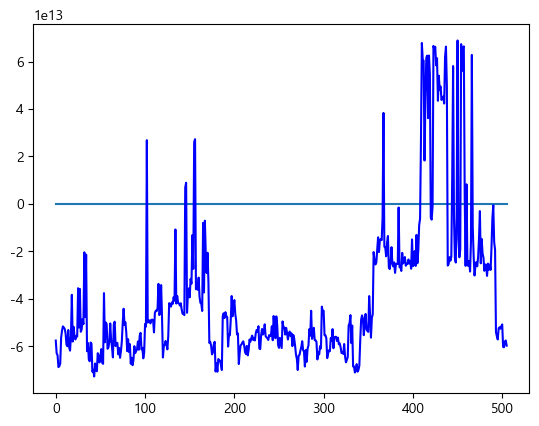

In [481]:
plt.plot(y)
plt.plot(pred1, 'b')
plt.show()

4) 각각의 결정계수값을 구하시요.

In [475]:
from sklearn.metrics import r2_score

In [476]:
r2_score(y, pred) # model = LinearRegression

0.7406426641094095

In [477]:
model.score(x,y) # LinearRegression

0.7406426641094095

In [478]:
r2_score(y, pred1) # model1 = SGDRegressor

-2.990955021516653e+25

In [479]:
model1.score(x,y) # SGDRegressor

-2.990955021516653e+25